# CPTAC-publication-compare-plot
6.28.24

todo: add description. 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# plotting templates
sns.set(context="talk", style="ticks") 
pal = sns.color_palette("tab10")

#### Create a dataframe to hold the results to be plotted
These results come from `DA-analysis-lupine`. 

In [2]:
cohorts = ["BRCA", "CCRCC", "COAD", "GBM", "HGSC", "HNSCC", "LSCC", "LUAD", "PDAC", "UCEC"]
savage2024_DE_genes=[np.nan, 2126, 1986, np.nan, 1376, 2306, 2855, 2914, 1431, 999]
n_overlap=[np.nan, 2020, 1954, np.nan, 1322, 2118, 2811, 2851, 1267, 802]

plotter = pd.DataFrame(columns=["cohorts", "savage2024", "n_overlap"])
plotter["cohorts"] = cohorts
plotter["savage2024"] = savage2024_DE_genes
plotter["n_overlap"] = n_overlap

#### Get the percentage of overlap

In [3]:
overlap_frac = plotter["n_overlap"] / plotter["savage2024"]
plotter["overlap_frac"] = overlap_frac
plotter["savage_exclusive"] = 1 - plotter["overlap_frac"]

#### Get rid of the two cohorts we don't have overlap data for

In [6]:
plotter = plotter.drop([0, 3])

#### Get stacked barplot 

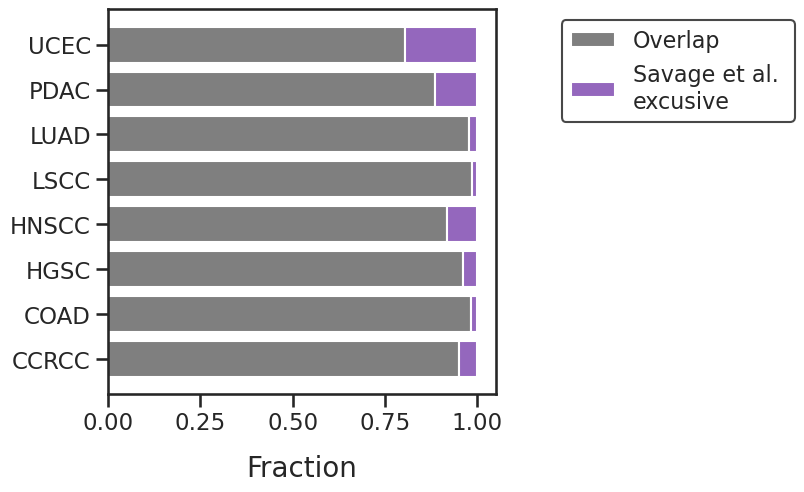

In [13]:
plt.figure(figsize=(5,5))

plt.barh(
    plotter["cohorts"], plotter["overlap_frac"], 
    color="#7f7f7f", label="Overlap",
)
plt.barh(
    plotter["cohorts"], plotter["savage_exclusive"], 
    left=plotter["overlap_frac"], color="#9467bd", label="Savage et al. \nexcusive",
)

plt.xlabel("Fraction", size=20, labelpad=14)
plt.ylabel("", size=20, labelpad=14)

#plt.xticks(rotation=90)
plt.legend(title="", edgecolor="k", prop={'size': 16}, 
           loc="upper right", bbox_to_anchor=(1.8, 1.0),
)
plt.show()